# Atelier Préparation de Données Textuelles

Pipeline complet de préparation d'un corpus d'avis clients pour la classification de sentiment.

## Imports

In [6]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

## Partie 1 – Exploration du corpus

### 1.1 Charger les données CSV

In [7]:
df = pd.read_csv("../data/smart_reviews_raw.csv")
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,positif,5,fr


### 1.2 Combien d'avis contient le dataset ?

In [8]:
print(f"Nombre d'avis : {len(df)}")

Nombre d'avis : 1200


### 1.3 Combien de colonnes possède-t-il ?

In [9]:
print(f"Nombre de colonnes : {df.shape[1]}")
print(df.columns.tolist())

Nombre de colonnes : 8
['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### 1.4 Quel est le type de chaque colonne ?

In [10]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 1.5 Existe-t-il des valeurs manquantes ?

In [11]:
manquantes = pd.DataFrame({
    "nb_manquantes": df.isna().sum(),
    "pourcentage": (df.isna().mean() * 100).round(2)
})
manquantes

,nb_manquantes,pourcentage
id_avis,0,0.00
date,0,0.00
source,0,0.00
produit,0,0.00
texte,5,0.42
sentiment,0,0.00
note,0,0.00
langue,0,0.00


### 1.6 Identifier quelques types de texte

On définit un masque booléen pour chaque type de texte à repérer : texte normal, vide, avec URL, mention, hashtag, emoji, beaucoup de ponctuation, en majuscules, avec répétition de caractères. On affiche ensuite quelques exemples de chaque type.

#### Mini-cours : les expressions régulières (regex)

Une **regex** est un motif qui décrit une forme de texte à repérer (une URL, une mention, un emoji…). Avec pandas, on l'utilise via `str.contains(motif, regex=True)`, qui renvoie `True` si le motif est trouvé dans le texte.

| Symbole | Signification | Exemple |
|---|---|---|
| `.` | n'importe quel caractère | `a.c` → "abc", "a9c" |
| `\w` | lettre, chiffre ou `_` | `\w` → "a", "7" |
| `\S` | tout caractère sauf l'espace | `\S` → "h", "/" |
| `[abc]` | un caractère parmi ceux listés | `[!?.]` → "!" ou "?" ou "." |
| `+` | 1 fois ou plus | `\w+` → "bonjour" |
| `{2,}` | 2 fois ou plus | `[!?]{2,}` → "!!!" |
| `\|` | ou | `http\|www` |
| `( )` | groupe (mémorisé) | `(.)` |
| `\1` | répète le groupe n°1 | `(.)\1` → "oo", "ss" |

**Les motifs utilisés ici**

- `@\w+` : un `@` suivi de lettres/chiffres, donc une **mention** (`@support`).
- `#\w+` : un `#` suivi de lettres/chiffres, donc un **hashtag** (`#top`).
- `https?://\S+` : "http" + "s" facultatif (`?` = 0 ou 1 fois) + `://` + tout jusqu'au prochain espace, donc une **URL**.
- `[!?.,;:]{2,}` : au moins 2 signes de ponctuation à la suite, donc de la **ponctuation répétée** (`!!!`, `???`).
- `(.)\1{2,}` : un caractère suivi de lui-même au moins 2 fois de plus, donc une **répétition de caractères** (`toooop`).
- `[\U0001F300-\U0001FAFF...]` : des **plages Unicode** où se trouvent les emojis.

In [12]:
# Version sans NaN pour appliquer les regex (df n'est pas modifié)
txt = df["texte"].fillna("").astype(str)

# Motifs regex
pat_url      = r"(https?://\S+|www\.\S+)"
pat_mention  = r"@\w+"
pat_hashtag  = r"#\w+"
pat_emoji    = (r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF"
                r"\U0001F000-\U0001F2FF\U0001F900-\U0001F9FF]")
pat_ponct    = r"[!?.,;:]{2,}"       # ponctuation répétée (!!!, ???, ...)
pat_repet    = r"(.)\1{2,}"          # même caractère 3 fois ou plus (topppp, sooo)

# Masques par type de texte
masques = {
    "vide":                  df["texte"].isna() | (txt.str.strip() == ""),
    "avec URL":              txt.str.contains(pat_url, regex=True, case=False),
    "avec mention":          txt.str.contains(pat_mention, regex=True),
    "avec hashtag":          txt.str.contains(pat_hashtag, regex=True),
    "avec emojis":           txt.str.contains(pat_emoji, regex=True),
    "beaucoup de ponctuation": txt.str.contains(pat_ponct, regex=True),
    "en majuscules":         txt.str.isupper() & (txt.str.len() > 3),
    "répétition de caractères": txt.str.contains(pat_repet, regex=True),
}

# Texte "normal" = aucun des cas particuliers ci-dessus
masque_special = pd.concat(masques.values(), axis=1).any(axis=1)
masques = {"normal": ~masque_special, **masques}

# Effectifs par type
resume_types = pd.DataFrame({
    "nb_avis": {k: int(m.sum()) for k, m in masques.items()}
})
resume_types["pourcentage"] = (resume_types["nb_avis"] / len(df) * 100).round(2)
resume_types

C:\Users\other\AppData\Local\Temp\ipykernel_17632\877018334.py:16: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "avec URL":              txt.str.contains(pat_url, regex=True, case=False),
C:\Users\other\AppData\Local\Temp\ipykernel_17632\877018334.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "répétition de caractères": txt.str.contains(pat_repet, regex=True),


,nb_avis,pourcentage
normal,344,28.67
vide,6,0.50
avec URL,143,11.92
avec mention,128,10.67
avec hashtag,127,10.58
avec emojis,192,16.00
beaucoup de ponctuation,141,11.75
en majuscules,144,12.00
répétition de caractères,165,13.75


In [13]:
for nom, masque in masques.items():
    print(f"\n===== {nom.upper()} ({masque.sum()} avis) =====")
    exemples = df.loc[masque, "texte"].head(3)
    if exemples.empty:
        print("Aucun exemple")
    for e in exemples:
        print(" -", repr(e))


===== NORMAL (344 avis) =====
 - 'Très  bonne  expérience,  simple  et  efficace.'
 - 'Produit  parfait,  rien  à  signaler.'
 - 'Le  produit  correspond  globalement  à  la  description.'

===== VIDE (6 avis) =====
 - nan
 - nan
 - nan

===== AVEC URL (143 avis) =====
 - 'Produit parfait, rien à signaler. https://example.com/commande/17'
 - 'Très bonne expérience, simple et efficace. https://example.com/commande/31'
 - 'Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32'

===== AVEC MENTION (128 avis) =====
 - '@client Livraison rapide et produit conforme à mes attentes.'
 - '@client Service client réactif et commande reçue rapidement.'
 - '@client La qualité est correcte sans être exceptionnelle.'

===== AVEC HASHTAG (127 avis) =====
 - 'Très satisfait de mon achat 👍 #avis'
 - "La batterie tient vraiment bien et l'écran est superbe. #avis"
 - 'Produit correct pour son prix. #avis'

===== AVEC EMOJIS (192 avis) =====
 - 'Très satisfait de mon achat

### 1.7 Mesurer la longueur des textes

On crée la colonne `longueur` (nombre de caractères de chaque avis), puis on calcule : minimum, maximum, moyenne, médiane et quartiles. Les valeurs manquantes sont comptées comme des textes de longueur 0.

In [14]:
# Nombre de caractères de chaque avis (NaN -> texte vide -> longueur 0)
df["longueur"] = df["texte"].fillna("").astype(str).str.len()

print(f"Longueur minimale : {df['longueur'].min()}")
print(f"Longueur maximale : {df['longueur'].max()}")
print(f"Longueur moyenne  : {df['longueur'].mean():.2f}")
print(f"Médiane           : {df['longueur'].median()}")
print(f"Q1 (25 %)         : {df['longueur'].quantile(0.25)}")
print(f"Q3 (75 %)         : {df['longueur'].quantile(0.75)}")

Longueur minimale : 0
Longueur maximale : 636
Longueur moyenne  : 48.96
Médiane           : 48.0
Q1 (25 %)         : 37.0
Q3 (75 %)         : 56.0


### 1.8 Visualiser la distribution de la longueur des avis

On commence par l'histogramme, qui montre la forme générale de la distribution des longueurs.

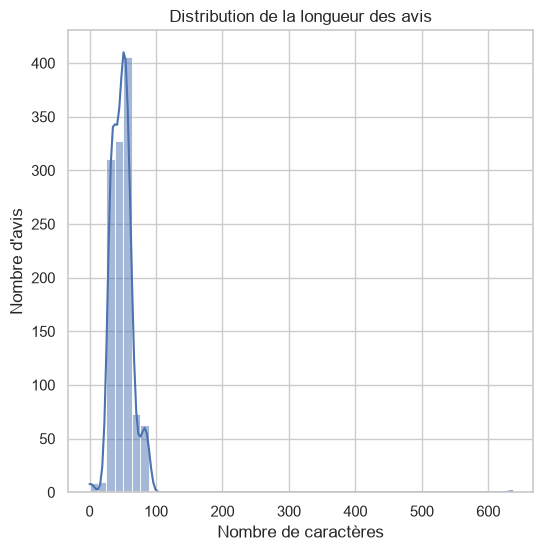

In [15]:
plt.figure(figsize=(6, 6))
sns.histplot(df["longueur"], bins=50, kde=True)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")
plt.show()

Le boxplot met en évidence les valeurs extrêmes : les points isolés au-delà des moustaches sont des textes dont la longueur sort de la norme.

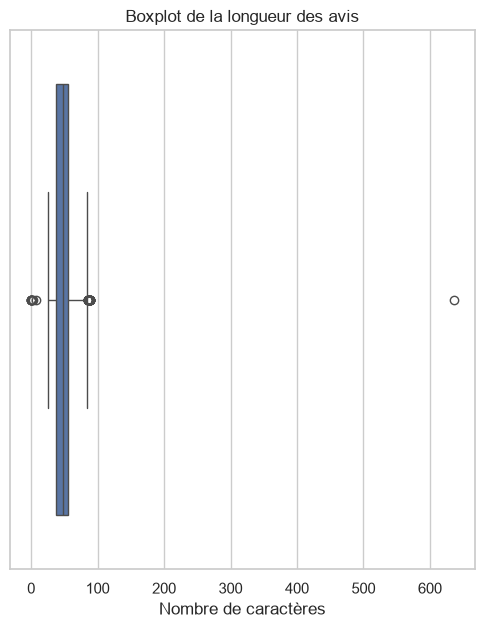

In [16]:
plt.figure(figsize=(6, 7))
sns.boxplot(x=df["longueur"])
plt.title("Boxplot de la longueur des avis")
plt.xlabel("Nombre de caractères")
plt.show()

#### Réponse 8.a) Existe-t-il des textes anormalement longs ?

**Oui, mais très peu.** Le boxplot montre un cas extrême isolé, à environ 635 caractères, très loin du reste des avis. La médiane est d'environ 50 caractères et la boîte s'étend d'environ 30 à 60 caractères : la grande majorité des avis sont donc courts et de longueur homogène.

Un petit groupe de points apparaît aussi juste après la moustache droite, autour de 85-90 caractères. Ce sont des textes un peu plus longs que la norme, mais sans excès.

Le texte de 635 caractères est une valeur aberrante. Il peut s'agir d'un avis très détaillé ou d'une erreur de collecte, et il faudra l'examiner lors du nettoyage.

#### Réponse 8.b) Existe-t-il beaucoup de textes très courts ?

**Non, ils restent peu nombreux.** La grande majorité des avis se situent entre environ 30 et 60 caractères. Seuls quelques points isolés apparaissent à gauche du boxplot, entre 0 et 10 caractères environ : ce sont probablement des textes vides ou quasi vides.

Ces textes apportent peu d'information pour déterminer le sentiment. Ils seront traités lors du nettoyage : suppression des textes vides, examen au cas par cas des textes très courts.

### 1.9 Détecter les textes vides

On distingue trois cas :
- **valeur manquante** (`NaN`) ;
- **chaîne vide** (`""`) ;
- **chaîne contenant uniquement des espaces** (`"   "`).

In [17]:
# Cas 1 : valeurs manquantes
vide_nan = df["texte"].isna()

# Cas 2 : chaînes vides
vide_chaine = df["texte"].fillna("x").astype(str).eq("")

# Cas 3 : chaînes ne contenant que des espaces (mais pas vides)
vide_espaces = (
    df["texte"].fillna("x").astype(str).str.strip().eq("")
    & ~vide_chaine
)

# Total : tous les textes inexploitables
vide_total = vide_nan | vide_chaine | vide_espaces

resume_vides = pd.DataFrame({
    "nb_avis": {
        "Valeurs manquantes (NaN)": int(vide_nan.sum()),
        "Chaînes vides": int(vide_chaine.sum()),
        "Uniquement des espaces": int(vide_espaces.sum()),
        "TOTAL textes vides": int(vide_total.sum()),
    }
})
resume_vides["pourcentage"] = (resume_vides["nb_avis"] / len(df) * 100).round(2)
resume_vides

,nb_avis,pourcentage
Valeurs manquantes (NaN),5,0.42
Chaînes vides,0,0.00
Uniquement des espaces,1,0.08
TOTAL textes vides,6,0.50


In [18]:
# Cas 1 : valeurs manquantes
vide_nan = df["texte"].isna()

# Cas 2 : chaînes vides
vide_chaine = df["texte"].fillna("x").astype(str).eq("")

# Cas 3 : chaînes ne contenant que des espaces (mais pas vides)
vide_espaces = (
    df["texte"].fillna("x").astype(str).str.strip().eq("")
    & ~vide_chaine
)

# Total : tous les textes inexploitables
vide_total = vide_nan | vide_chaine | vide_espaces

resume_vides = pd.DataFrame({
    "nb_avis": {
        "Valeurs manquantes (NaN)": int(vide_nan.sum()),
        "Chaînes vides": int(vide_chaine.sum()),
        "Uniquement des espaces": int(vide_espaces.sum()),
        "TOTAL textes vides": int(vide_total.sum()),
    }
})
resume_vides["pourcentage"] = (resume_vides["nb_avis"] / len(df) * 100).round(2)
resume_vides

,nb_avis,pourcentage
Valeurs manquantes (NaN),5,0.42
Chaînes vides,0,0.00
Uniquement des espaces,1,0.08
TOTAL textes vides,6,0.50


In [19]:
# Afficher les 10 premières lignes dont le texte est vide ou contient seulement des espaces,
# en sélectionnant uniquement les colonnes id_avis, source, texte et sentiment.
df.loc[vide_total, ["id_avis", "source", "texte", "sentiment"]].head(10)

,id_avis,source,texte,sentiment
46,AV0047,réseaux_sociaux,NaN,positif
108,AV0109,email,NaN,positif
310,AV0311,réseaux_sociaux,NaN,positif
640,AV0641,réseaux_sociaux,NaN,positif
781,AV0782,email,NaN,neutre
951,AV0952,web,,positif


### 1.10 Détecter les doublons sur le texte

On repère les avis dont le texte apparaît plusieurs fois. Les textes vides sont exclus du calcul, car ils ont déjà été détectés à la question 9.

`duplicated()` marque les copies d'un texte déjà rencontré, sans compter la première occurrence.

In [20]:
# On ne regarde que les textes non vides
df_non_vides = df[~vide_total]

nb_doublons = df_non_vides["texte"].duplicated().sum()

print(f"Nombre de doublons sur le texte : {nb_doublons}")
print(f"Pourcentage du dataset          : {nb_doublons / len(df) * 100:.2f} %")

Nombre de doublons sur le texte : 877
Pourcentage du dataset          : 73.08 %


### 1.11 Les classes sont-elles équilibrées ?

On compte le nombre d'avis par classe de sentiment (colonne `sentiment`). Les valeurs manquantes sont incluses (`dropna=False`) pour ne pas les cacher.

In [21]:
effectifs = df["sentiment"].value_counts(dropna=False)
pourcentages = (df["sentiment"].value_counts(normalize=True, dropna=False) * 100).round(2)

repartition = pd.DataFrame({"nb_avis": effectifs, "pourcentage": pourcentages})
repartition

,nb_avis,pourcentage
sentiment,,
positif,776,64.67
neutre,246,20.50
negatif,178,14.83


#### Réponse 12) Classe majoritaire

La classe majoritaire est **« positif »**, avec 776 avis (64,67 % du dataset).



#### Réponse 13) Métriques de classification

Les classes sont déséquilibrées (65 % positif, 20 % neutre, 15 % négatif). L'**accuracy** est donc trompeuse : un modèle qui prédirait toujours « positif » obtiendrait environ 65 % sans détecter aucun avis négatif ou neutre.

On privilégie des métriques qui évaluent chaque classe séparément :

- **Précision** par classe : parmi les avis prédits dans une classe, quelle part est correcte.
- **Rappel** par classe : parmi les avis réellement de cette classe, quelle part est retrouvée. Le rappel de la classe « négatif » est le plus important, car l'entreprise veut repérer les clients mécontents.
- **F1-score** par classe : moyenne harmonique de la précision et du rappel.
- **F1 macro** : moyenne des F1 de chaque classe, sans tenir compte de leur taille.
- **F1 pondéré** : moyenne pondérée par la taille des classes.

**La métrique la plus adaptée est le F1 macro** : elle donne le même poids à chaque classe, y compris aux classes minoritaires (négatif et neutre), et n'est donc pas faussée par la domination de la classe « positif ».

### 1.14 Détecter les caractères particuliers

On compte, pour chaque type de caractère particulier, le nombre d'avis qui en contiennent : emojis, URLs, hashtags, mentions, chiffres, caractères spéciaux, ponctuation répétée et répétition de caractères.

Pour les **caractères spéciaux**, on retire d'abord les URLs, mentions, hashtags et emojis (déjà comptés à part), puis on cherche ce qui reste en dehors des lettres, chiffres, espaces et de la ponctuation courante.

In [22]:
# Motifs supplémentaires
pat_chiffres = r"\d"
pat_special = r"[^\w\s.,;:!?'’\"()\-]"   # tout sauf lettres, chiffres, espaces, ponctuation courante

# Texte débarrassé des éléments déjà comptés, pour ne garder que les caractères spéciaux "restants"
txt_sans_autres = (
    txt.str.replace(pat_url, " ", regex=True, case=False)
       .str.replace(pat_mention, " ", regex=True)
       .str.replace(pat_hashtag, " ", regex=True)
       .str.replace(pat_emoji, " ", regex=True)
)

caracteres_particuliers = {
    "Emojis":                 txt.str.contains(pat_emoji, regex=True),
    "URLs":                   txt.str.contains(pat_url, regex=True, case=False),
    "Hashtags":               txt.str.contains(pat_hashtag, regex=True),
    "Mentions":               txt.str.contains(pat_mention, regex=True),
    "Chiffres":               txt.str.contains(pat_chiffres, regex=True),
    "Caractères spéciaux":    txt_sans_autres.str.contains(pat_special, regex=True),
    "Ponctuation répétée":    txt.str.contains(pat_ponct, regex=True),
    "Répétition de caractères": txt.str.contains(pat_repet, regex=True),
}

resume_caracteres = pd.DataFrame({
    "nb_avis": {k: int(m.sum()) for k, m in caracteres_particuliers.items()}
})
resume_caracteres["pourcentage"] = (resume_caracteres["nb_avis"] / len(df) * 100).round(2)
resume_caracteres.sort_values("nb_avis", ascending=False)

C:\Users\other\AppData\Local\Temp\ipykernel_17632\180930505.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "URLs":                   txt.str.contains(pat_url, regex=True, case=False),
C:\Users\other\AppData\Local\Temp\ipykernel_17632\180930505.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "Répétition de caractères": txt.str.contains(pat_repet, regex=True),


,nb_avis,pourcentage
Emojis,192,16.00
Répétition de caractères,165,13.75
URLs,143,11.92
Chiffres,142,11.83
Ponctuation répétée,141,11.75
Mentions,128,10.67
Hashtags,127,10.58
Caractères spéciaux,0,0.00


### 1.15 Visualiser et commenter le nombre d'avis par source

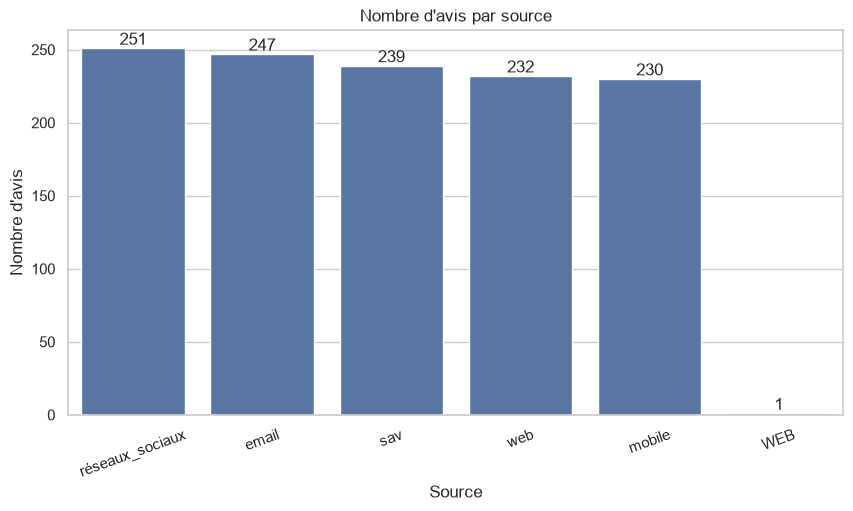

In [23]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="source", order=df["source"].value_counts().index)
ax.bar_label(ax.containers[0])
plt.title("Nombre d'avis par source")
plt.xlabel("Source")
plt.ylabel("Nombre d'avis")
plt.xticks(rotation=20)
plt.show()

#### Commentaire 15) Avis par source

Le dataset compte cinq sources principales, avec une répartition **très équilibrée** : réseaux sociaux (251 avis), email (247), SAV (239), web (232) et mobile (230). 

On observe aussi une **incohérence de saisie** : une source « WEB » (en majuscules) n'apparaît qu'une seule fois, à côté de « web » (232 avis). Il s'agit de la même source écrite avec une casse différente. 


### 1.16 Visualiser et commenter le nombre d'avis par produit

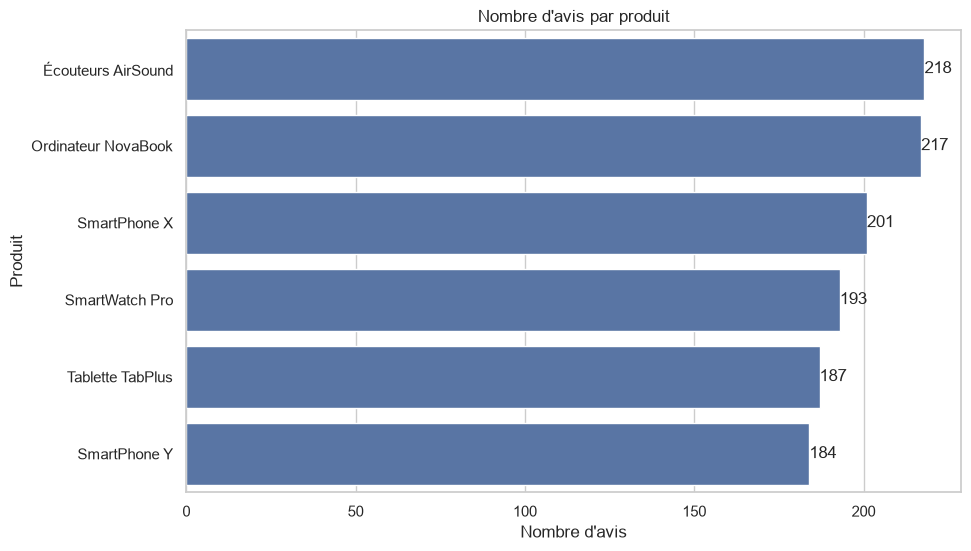

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, y="produit", order=df["produit"].value_counts().index)
ax.bar_label(ax.containers[0])
plt.title("Nombre d'avis par produit")
plt.xlabel("Nombre d'avis")
plt.ylabel("Produit")
plt.show()

#### Commentaire 16) Avis par produit

Le dataset compte **six produits**, avec une répartition **assez équilibrée** : Écouteurs AirSound (218 avis), Ordinateur NovaBook (217), SmartPhone X (201), SmartWatch Pro (193), Tablette TabPlus (187) et SmartPhone Y (184). L'écart entre le produit le plus commenté et le moins commenté est d'environ 34 avis, donc aucun produit ne domine le corpus.

Contrairement à la colonne `source`, on ne relève **pas d'incohérence de saisie** : chaque produit apparaît sous un seul nom.



## Partie 2 – Nettoyage

On travaille sur une copie `df_clean` pour conserver le dataset brut `df` intact.

### 2.1 Supprimer les lignes contenant des valeurs manquantes de texte

In [29]:
df_clean = df.copy()
nb_avant = len(df_clean)

df_clean = df_clean.dropna(subset=["texte"]).reset_index(drop=True)

print(f"Avant : {nb_avant} avis")
print(f"Supprimés : {nb_avant - len(df_clean)} avis")
print(f"Après : {len(df_clean)} avis")

Avant : 1200 avis
Supprimés : 5 avis
Après : 1195 avis


### 2.3 Supprimer les URLs

Les URLs n'apportent aucune information sur le sentiment : elles sont remplacées par un espace. On crée la colonne `texte_clean` (copie de `texte`) qui recevra tous les traitements de nettoyage.

In [35]:
df_clean["texte_clean"] = df_clean["texte"]

nb_avant = df_clean["texte_clean"].str.contains(pat_url, regex=True, case=False).sum()

df_clean["texte_clean"] = df_clean["texte_clean"].str.replace(pat_url, " ", regex=True, case=False)

nb_apres = df_clean["texte_clean"].str.contains(pat_url, regex=True, case=False).sum()

print(f"Avis avec URL avant : {nb_avant}")
print(f"Avis avec URL après : {nb_apres}")

Avis avec URL avant : 143
Avis avec URL après : 0


C:\Users\other\AppData\Local\Temp\ipykernel_17632\1827932833.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nb_avant = df_clean["texte_clean"].str.contains(pat_url, regex=True, case=False).sum()
C:\Users\other\AppData\Local\Temp\ipykernel_17632\1827932833.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  nb_apres = df_clean["texte_clean"].str.contains(pat_url, regex=True, case=False).sum()


### 2.4 Traiter les mentions et hashtags

Stratégie retenue pour une classification de sentiment :

- **Mentions (`@utilisateur`) : suppression.** Ce sont des noms de comptes ou de marques, qui n'apportent aucune information sur le sentiment et qui varient d'un avis à l'autre (bruit).
- **Hashtags (`#top`) : on conserve le mot, on retire le symbole `#`.** Un hashtag comme `#déçu` ou `#excellent` exprime directement une opinion : le supprimer entièrement ferait perdre un signal utile au modèle.

In [36]:
nb_mentions_avant = df_clean["texte_clean"].str.contains(pat_mention, regex=True).sum()
nb_hashtags_avant = df_clean["texte_clean"].str.contains(pat_hashtag, regex=True).sum()

# Mentions : supprimées
df_clean["texte_clean"] = df_clean["texte_clean"].str.replace(pat_mention, " ", regex=True)

# Hashtags : on garde le mot, on retire le #
df_clean["texte_clean"] = df_clean["texte_clean"].str.replace(r"#(\w+)", r"\1", regex=True)

nb_mentions_apres = df_clean["texte_clean"].str.contains(pat_mention, regex=True).sum()
nb_hashtags_apres = df_clean["texte_clean"].str.contains(pat_hashtag, regex=True).sum()

print(f"Avis avec mention : {nb_mentions_avant} -> {nb_mentions_apres}")
print(f"Avis avec hashtag : {nb_hashtags_avant} -> {nb_hashtags_apres}")

Avis avec mention : 128 -> 0
Avis avec hashtag : 127 -> 0


### 2.5 Nettoyer les espaces

Les suppressions précédentes (URLs, mentions) ont laissé des espaces en trop. On :
- remplace toute suite d'espaces (y compris tabulations et retours à la ligne) par un **seul espace** ;
- retire les espaces au **début et à la fin** du texte.

In [37]:
nb_avant = df_clean["texte_clean"].str.contains(r"\s{2,}|^\s|\s$", regex=True).sum()

df_clean["texte_clean"] = (
    df_clean["texte_clean"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

nb_apres = df_clean["texte_clean"].str.contains(r"\s{2,}|^\s|\s$", regex=True).sum()

print(f"Avis avec espaces en trop : {nb_avant} -> {nb_apres}")

Avis avec espaces en trop : 396 -> 0
